In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
import warnings
warnings.filterwarnings("ignore")


In [6]:
df = pd.read_csv('/Users/georgezla/Desktop/MACHINE LEARNING/DIABETES/diabetes2.csv')

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome
0    500
1    268
Name: count, dtype: int64


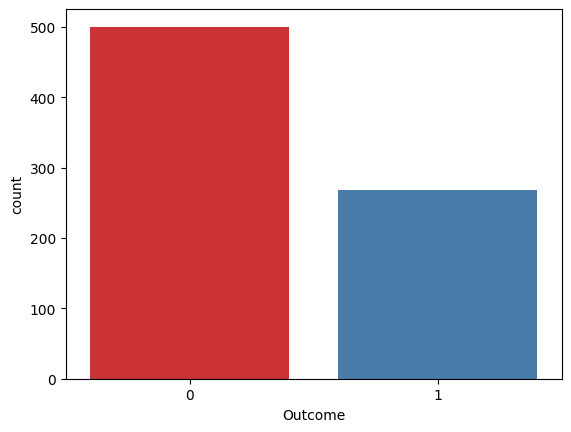

In [11]:
sns.countplot(data=df , x='Outcome',palette='Set1')
print(df['Outcome'].value_counts())



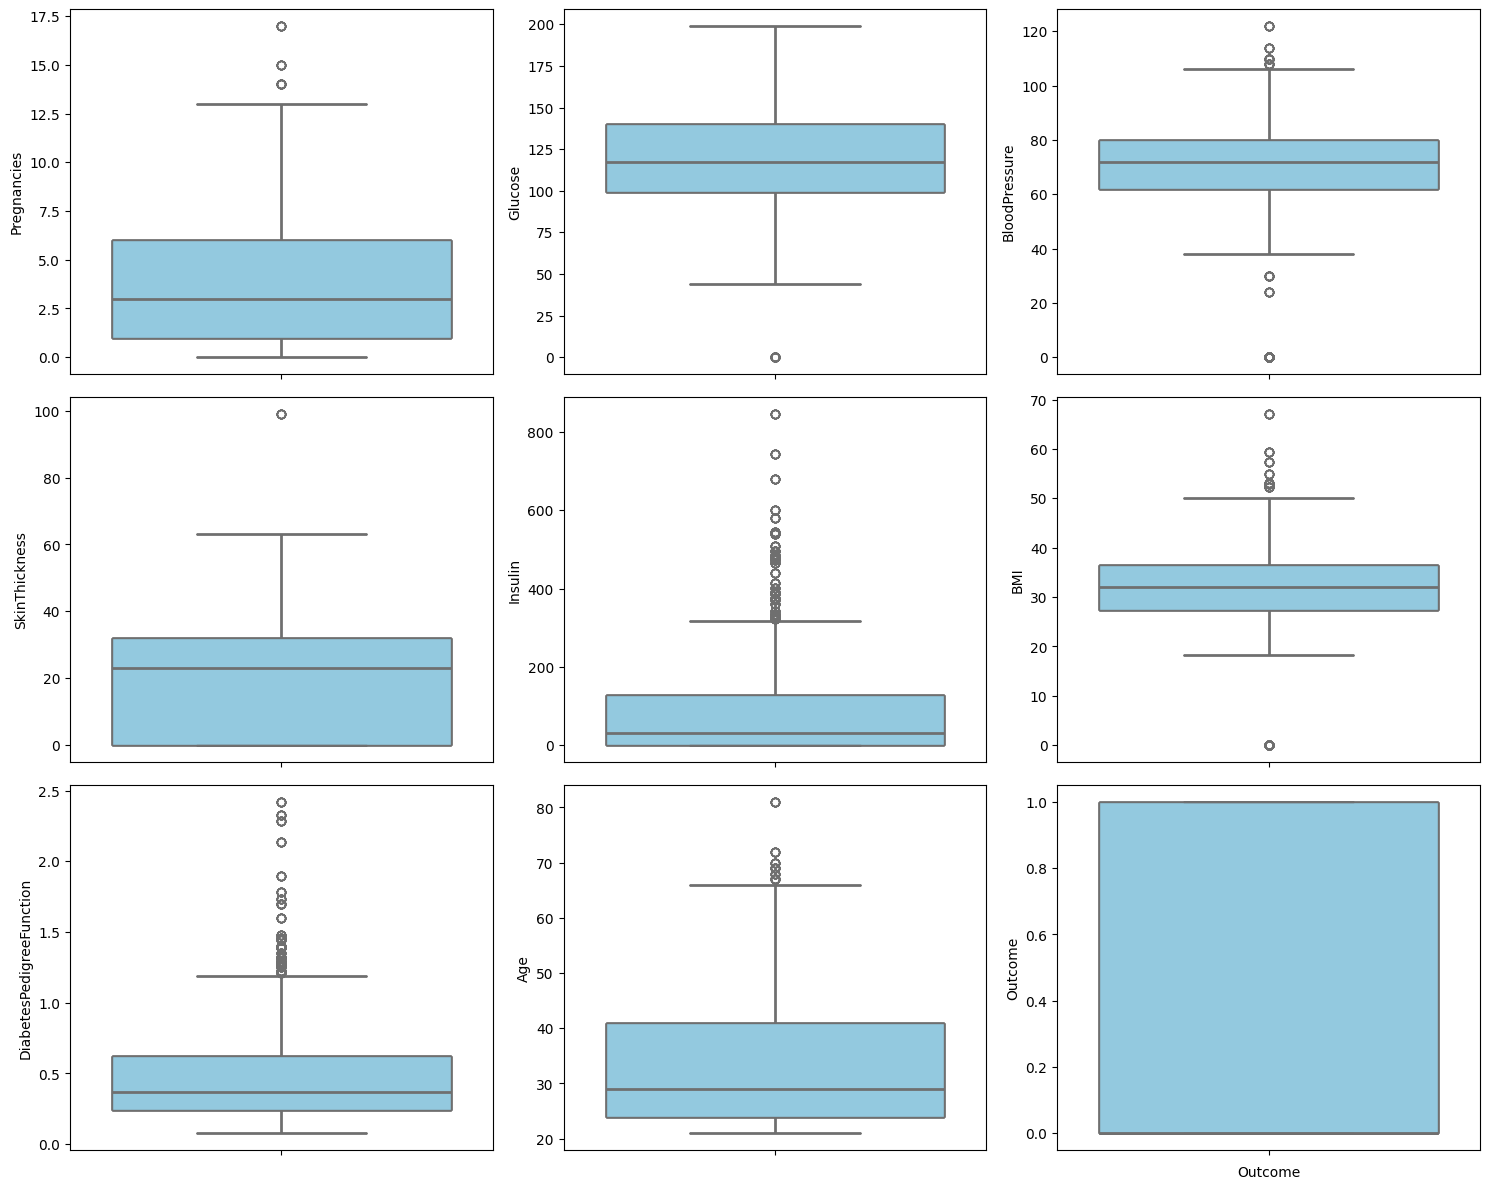

In [12]:
numeric_cols = df.select_dtypes(include='number').columns
n_cols = 3
rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig , axes =plt.subplots(rows,n_cols, figsize=((5*n_cols, 4*rows)))
axes = axes.flatten()

for i , col in enumerate(numeric_cols):
    for i, col in enumerate(numeric_cols):
        sns.boxplot(
        data=df,
        y=col,            
        color='skyblue',
        ax=axes[i]
    )
    axes[i].set_xlabel(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



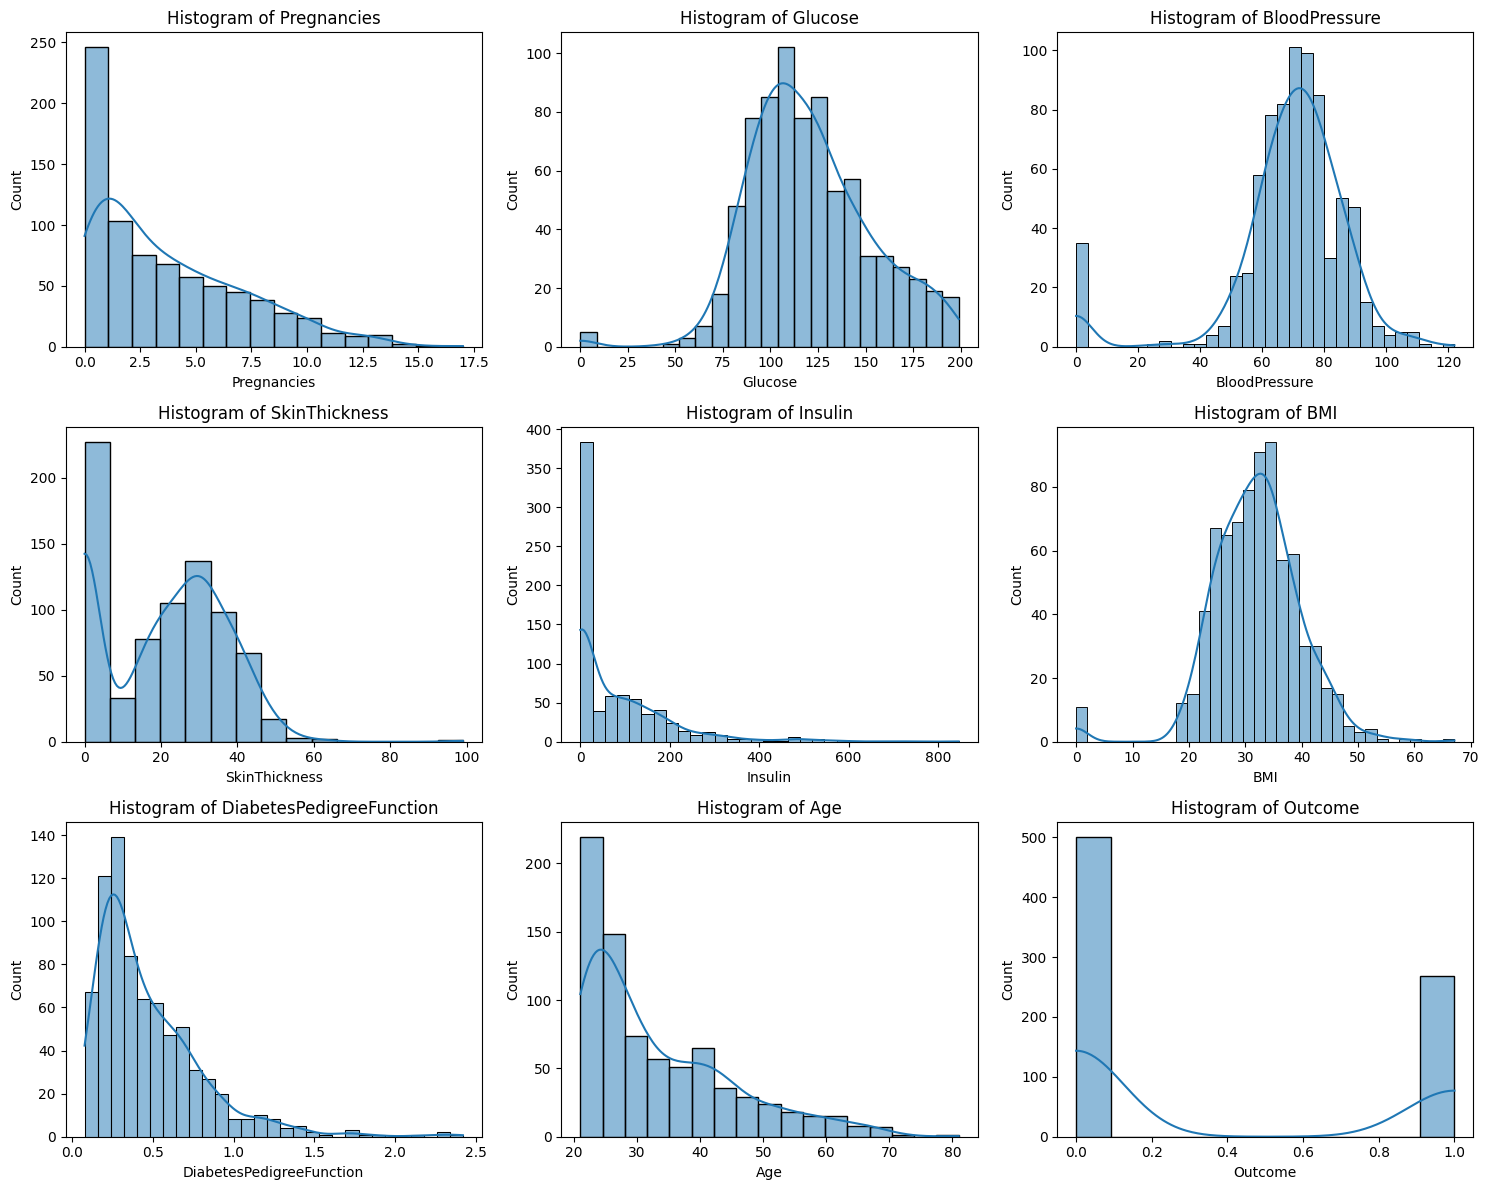

In [13]:
numeric_cols = df.select_dtypes(include='number').columns
n_cols = 3 
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, multiple='stack', kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')

# Αφαίρεση κενών axes αν υπάρχουν
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

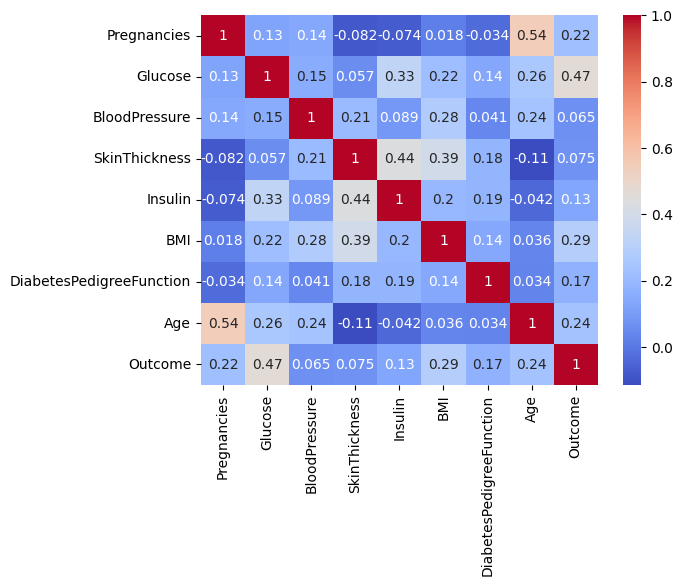

In [14]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [15]:
df_cleaned = df.apply(pd.to_numeric,errors='coerce')

columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_cleaned[columns_with_invalid_zeros] = df_cleaned[columns_with_invalid_zeros].replace(0, np.nan)

df_cleaned = df_cleaned.dropna(subset=['Glucose', 'BMI'])

df_cleaned = df_cleaned.fillna(df_cleaned.median())

In [16]:
Y = df_cleaned['Outcome']

In [17]:
X = df_cleaned.drop(columns=['Outcome'])

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
x_train,x_test,y_train,y_test = train_test_split(X_scaled,Y,random_state=42,test_size=0.2)

In [20]:
model = LogisticRegression()
model.fit(x_train,y_train)
pred = model.predict(x_test)
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Logistic Regression:
Accuracy: 0.7682119205298014
              precision    recall  f1-score   support

           0       0.76      0.89      0.82        91
           1       0.78      0.58      0.67        60

    accuracy                           0.77       151
   macro avg       0.77      0.74      0.74       151
weighted avg       0.77      0.77      0.76       151



In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

In [22]:
x_trainP,x_testP,y_trainP,y_testP = train_test_split(X_poly,Y,random_state=42,test_size=0.2)

Logistic Regression:
Accuracy: 0.7880794701986755
              precision    recall  f1-score   support

           0       0.79      0.89      0.84        91
           1       0.79      0.63      0.70        60

    accuracy                           0.79       151
   macro avg       0.79      0.76      0.77       151
weighted avg       0.79      0.79      0.78       151



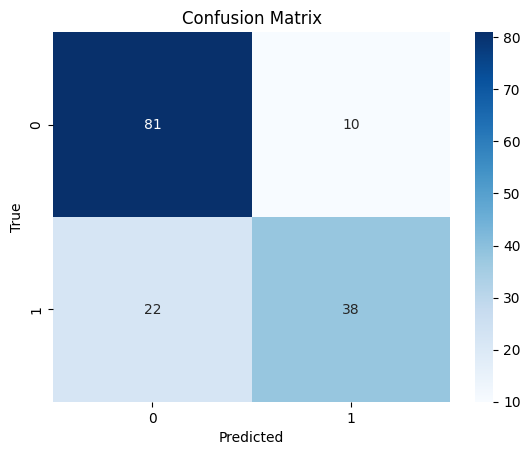

In [23]:
model2 = LogisticRegression(penalty='l2' , C=1)
model2.fit(x_trainP,y_trainP)
pred2 = model2.predict(x_testP)
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_testP, pred2))
print(classification_report(y_testP, pred2))


cm = confusion_matrix(y_testP, pred2)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(model2, x_trainP, y_trainP, cv=5, scoring='accuracy')
print(f"CV Accuracy: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")

CV Accuracy: 0.735 ± 0.027


Decision Tree Classifier:
Accuracy: 0.7682119205298014
              precision    recall  f1-score   support

           0       0.76      0.89      0.82        91
           1       0.78      0.58      0.67        60

    accuracy                           0.77       151
   macro avg       0.77      0.74      0.74       151
weighted avg       0.77      0.77      0.76       151



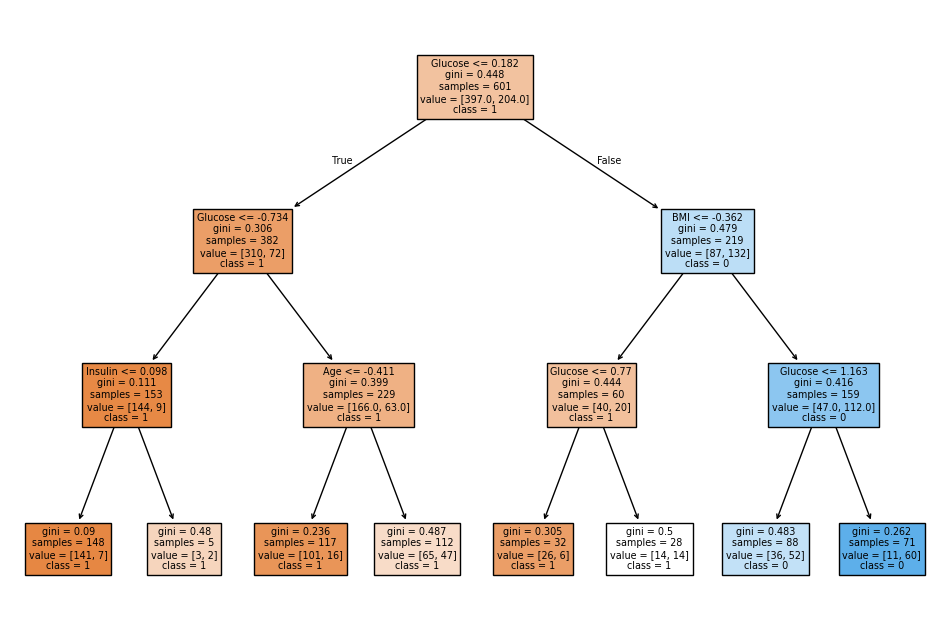

In [25]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=3,random_state=42)
dtree.fit(x_train,y_train)

tree_pred = model.predict(x_test)
print("Decision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(dtree, feature_names=X.columns, class_names=[str(c) for c in Y.unique()], filled=True)
plt.show()


 SCV:
Accuracy: 0.7814569536423841
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        91
           1       0.81      0.58      0.68        60

    accuracy                           0.78       151
   macro avg       0.79      0.75      0.76       151
weighted avg       0.79      0.78      0.77       151



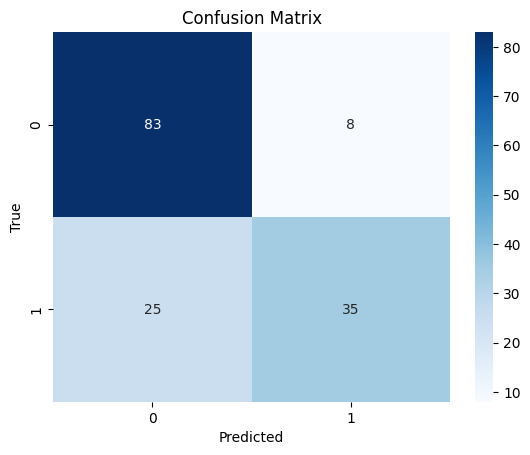

In [26]:
from sklearn.svm import SVC

svc_model = SVC(kernel='linear',C=1,gamma='scale',probability=True,random_state=42)

svc_model.fit(x_train,y_train)
svc_pred = svc_model.predict(x_test)

print(" SCV:")
print("Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))


cm = confusion_matrix(y_test, svc_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=9,
    random_state=42,
    class_weight="balanced"
     
)

rf_model.fit(x_train,y_train)

rf_pred = rf_model.predict(x_test)
print(" Random Forest:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score



# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation with F1-score
f1_scores = cross_val_score(rf_model, X, Y, cv=cv, scoring='f1_macro')

print(f"5-Fold CV F1-score: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")






 Random Forest:
Accuracy: 0.8079470198675497
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        91
           1       0.72      0.83      0.78        60

    accuracy                           0.81       151
   macro avg       0.80      0.81      0.80       151
weighted avg       0.82      0.81      0.81       151

5-Fold CV F1-score: 0.752 ± 0.009


In [28]:
import joblib

joblib.dump(rf_model, "diabetes_model.pkl")

['diabetes_model.pkl']